# Task 1 — SVM (Linear Kernel)

**Name:** Abdlrhman Hisham Ismail · **ID:** AI2617

Train a Support Vector Machine with **`kernel="linear"`** on Red Wine Quality (binary good/bad).
Feature scaling is applied because SVM is distance/margin based.


In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if "Task" in Path.cwd().name else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)

from data_utils import load_wine_binary, dataset_info

print(dataset_info())
X_train, X_test, y_train, y_test = load_wine_binary()
print(f"Train: {X_train.shape} | Test: {X_test.shape}")


Red Wine Quality (UCI / Kaggle) — binary label: good wine if quality >= 6. Features: fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free/total sulfur dioxide, density, pH, sulphates, alcohol.
Train: (1199, 11) | Test: (400, 11)


In [2]:
svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="linear", C=1.0, random_state=42)),
])

svm_linear.fit(X_train, y_train)
y_tr = svm_linear.predict(X_train)
y_te = svm_linear.predict(X_test)

print("=== SVM Linear ===")
print(f"Train Acc={accuracy_score(y_train, y_tr):.4f}  F1={f1_score(y_train, y_tr):.4f}")
print(f"Test  Acc={accuracy_score(y_test, y_te):.4f}  F1={f1_score(y_test, y_te):.4f}")
print("\nTest classification report:")
print(classification_report(y_test, y_te, target_names=["bad", "good"]))

# Support vectors count
n_sv = svm_linear.named_steps["clf"].n_support_
print(f"Support vectors per class: {n_sv} (total={n_sv.sum()})")


=== SVM Linear ===
Train Acc=0.7481  F1=0.7568
Test  Acc=0.7375  F1=0.7482

Test classification report:
              precision    recall  f1-score   support

         bad       0.71      0.75      0.73       186
        good       0.77      0.73      0.75       214

    accuracy                           0.74       400
   macro avg       0.74      0.74      0.74       400
weighted avg       0.74      0.74      0.74       400

Support vectors per class: [360 357] (total=717)


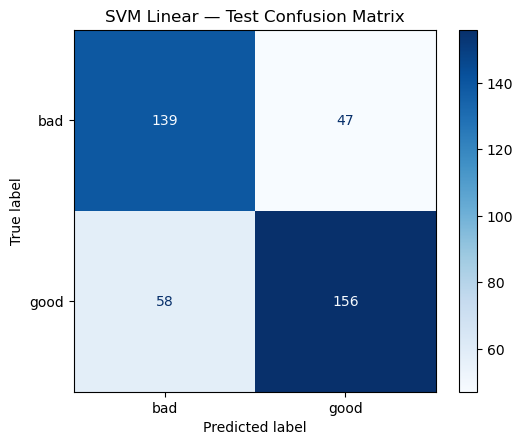

In [3]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_te, display_labels=["bad", "good"], ax=ax, cmap="Blues"
)
ax.set_title("SVM Linear — Test Confusion Matrix")
fig.tight_layout()
fig.savefig("plots/svm_linear_confusion.png", dpi=150)
plt.show()

pd.DataFrame([{
    "kernel": "linear",
    "C": 1.0,
    "train_acc": accuracy_score(y_train, y_tr),
    "train_f1": f1_score(y_train, y_tr),
    "test_acc": accuracy_score(y_test, y_te),
    "test_f1": f1_score(y_test, y_te),
    "n_support_vectors": int(n_sv.sum()),
}]).to_csv("results_svm_linear.csv", index=False)


## Notes

A **linear kernel** finds a separating hyperplane in the original feature space.  
It works well when classes are roughly linearly separable and is faster / more interpretable than RBF.
